### **[Forecasting Techniques That Align Sales Projections with Supply Chain Reality](https://blog.devgenius.io/10-forecasting-techniques-that-align-sales-projections-with-supply-chain-reality-6109f50674b1)**

> *Robust modeling approaches that reconcile demand forecasts with inventory dynamics and operational constraints*

In [1]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [2]:
import sys

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

import requests
from itertools import product
from datetime import datetime, timedelta

import streamlit as st

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

from textblob import TextBlob

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(suppress=True, precision=3)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

plt.style.use('ggplot')

%autosave 15

Autosaving every 15 seconds


##### **Lead Time-Adjusted Forecasting**

In [3]:
# SKU master data with lead time variability
skus = pd.DataFrame({
  "sku_id": ["X100", "Y200", "Z300"],
  "avg_daily_demand": [50, 30, 20],
  "std_daily_demand": [10, 8, 5],
  "avg_lead_time": [14, 30, 7],  # days
  "std_lead_time": [3, 10, 1],
  "supplier_risk_score": [0.3, 0.8, 0.2]  # 0-1 scale
})

# Calculate safety stock with lead time variation
def calculate_dynamic_safety_stock(row, service_level=0.95):
  """Safety stock incorporating lead time variability"""
  z_score = 1.65  # for 95% service level

  demand = row["avg_daily_demand"]
  demand_std = row["std_daily_demand"]
  lead_time_avg = row["avg_lead_time"]
  lead_time_std = row["std_lead_time"]

  # Combined standard deviation during lead time
  # Fixed: Use ** for exponentiation
  variance_demand = lead_time_avg * (demand_std ** 2)
  variance_lead_time = (demand ** 2) * (lead_time_std ** 2)

  combined_std = np.sqrt(variance_demand + variance_lead_time)

  # Adjust for supplier risk
  risk_multiplier = 1 + row["supplier_risk_score"]

  safety_stock = z_score * combined_std * risk_multiplier

  return round(safety_stock, 0)

skus["safety_stock_units"] = skus.apply(calculate_dynamic_safety_stock, axis=1)

# Adjust forecast based on supplier risk
def adjust_forecast_for_risk(row, forecast_periods=30):
  base_forecast = row["avg_daily_demand"] * forecast_periods
  risk_adjustment = row["supplier_risk_score"] * 0.15  # 15% penalty per risk unit
  adjusted_forecast = base_forecast * (1 + risk_adjustment)
  return round(adjusted_forecast, 0)

skus["risk_adjusted_forecast"] = skus.apply(adjust_forecast_for_risk, axis=1)
display(skus[["sku_id", "safety_stock_units", "risk_adjusted_forecast"]])

,sku_id,safety_stock_units,risk_adjusted_forecast
0,X100,332.000,1568.000
1,Y200,900.000,1008.000
2,Z300,47.000,618.000


##### **Probabilistic Forecasting (Beyond “Best Guess”)**

Probability of sales exceeding 150 units: 41.9%
50% confidence interval: [92, 190]


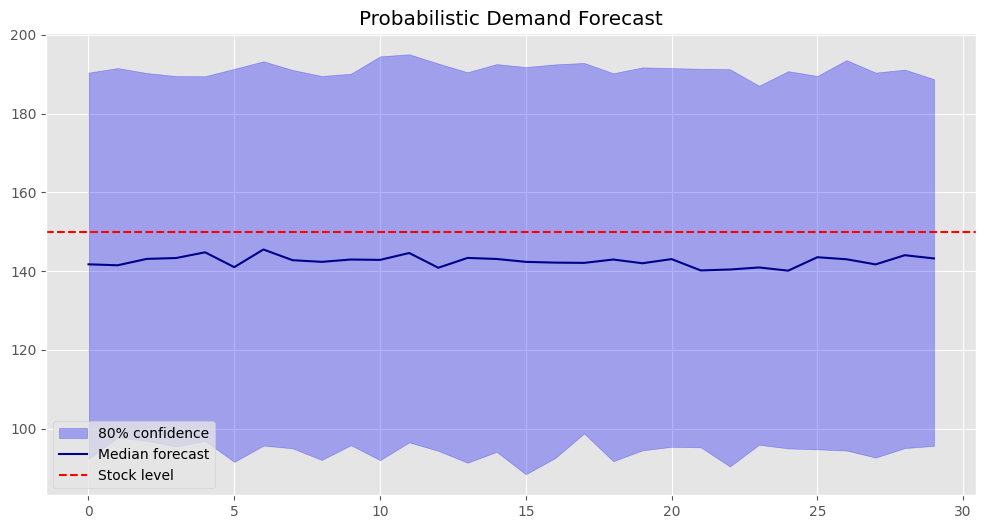

In [4]:
# Historical sales with high volatility
sales_data = np.array([120, 95, 180, 140, 200, 85, 160, 110, 190, 145])

# Fit distribution (using normal for simplicity)
mu, sigma = np.mean(sales_data), np.std(sales_data)

# Generate probabilistic forecast
forecast_periods = 30
simulations = 1000

# Monte Carlo simulation
probabilistic_forecast = np.random.normal(mu, sigma, (simulations, forecast_periods))

# Calculate percentiles
p10 = np.percentile(probabilistic_forecast, 10, axis=0)
p50 = np.percentile(probabilistic_forecast, 50, axis=0)
p90 = np.percentile(probabilistic_forecast, 90, axis=0)

# Probability of exceeding stock level
stock_level = 150
prob_exceed = np.mean(probabilistic_forecast > stock_level)

print(f"Probability of sales exceeding {stock_level} units: {prob_exceed:.1%}")
print(f"50% confidence interval: [{p10[0]:.0f}, {p90[0]:.0f}]")

# Visualize
plt.figure(figsize=(12, 6))
plt.fill_between(range(30), p10, p90, alpha=0.3, color='blue', label='80% confidence')
plt.plot(p50, color='darkblue', label='Median forecast')
plt.axhline(y=stock_level, color='red', linestyle='--', label='Stock level')
plt.title("Probabilistic Demand Forecast")
plt.legend()
plt.show()

##### **Cross-Functional “War Room” Sessions**

In [5]:
# Simulated cross-functional data
sales_input = pd.DataFrame({
  "product": ["A", "B", "C"],
  "sales_forecast": [150, 200, 180],
  "confidence": ["High", "Medium", "Low"],
  "assumptions": ["New marketing campaign", "Seasonal trend", "Uncertain economy"]
})

ops_input = pd.DataFrame({
  "product": ["A", "B", "C"],
  "capacity": [160, 190, 200],
  "material_constraint": ["None", "Chip shortage", "Steel delay"]
})

finance_input = pd.DataFrame({
  "product": ["A", "B", "C"],
  "margin_target": [0.30, 0.25, 0.35],
  "risk_adjustment": [-5, -10, -15]
})

print("/nSales")
display(sales_input)

print("/nOps")
display(ops_input)

print("/nFinance")
display(finance_input)

if not IN_COLAB:
  # Build war room dashboard
  st.title("Cross-Functional Forecast War Room")

  col1, col2, col3 = st.columns(3)

  with col1:
    st.subheader("Sales View")
    st.dataframe(sales_input)

  with col2:
    st.subheader("Operations View")
    st.dataframe(ops_input)

  with col3:
    st.subheader("Finance View")
    st.dataframe(finance_input)

  # Highlight misalignments
  st.subheader("Risk Alerts")
  for idx, row in sales_input.iterrows():
    product = row["product"]
    sales_fc = row["sales_forecast"]
    ops_cap = ops_input[ops_input["product"] == product]["capacity"].iloc[0]

    if sales_fc > ops_cap:
      st.error(f"Product {product}: Sales forecast ({sales_fc}) exceeds capacity ({ops_cap})")
    else:
      st.success(f"Product {product}: Forecast within capacity")

  # Devil's advocate questions
  st.subheader("Devil's Advocate Questions")
  questions = [
    "What if competitor launches similar product?",
    "What if key supplier fails?",
    "What if demand drops 30%?"
  ]

  for q in questions:
    st.checkbox(q)

#!streamlit run app.py &>/content/logs.txt &
#!npx localtunnel --port 8501

/nSales


,product,sales_forecast,confidence,assumptions
0,A,150,High,New marketing campaign
1,B,200,Medium,Seasonal trend
2,C,180,Low,Uncertain economy


/nOps


,product,capacity,material_constraint
0,A,160,None
1,B,190,Chip shortage
2,C,200,Steel delay


/nFinance


,product,margin_target,risk_adjustment
0,A,0.300,-5
1,B,0.250,-10
2,C,0.350,-15


##### **Demand Sensing with AI-Driven Real-Time Data**

In [6]:
# Simulate real-time data pipeline
def fetch_live_signals():
  """Fetch multiple real-time data streams"""
  # Simulated social media sentiment score
  tweets = ["love this product", "stock issues again", "great value"]
  sentiment = np.mean([TextBlob(t).sentiment.polarity for t in tweets])

  # Simulated weather API call
  weather_data = {"temperature": 75, "rainfall": 0.2}

  # Simulated competitor pricing
  competitor_price = 99.99

  return {
    "sentiment_score": sentiment,
    "temperature": weather_data["temperature"],
    "competitor_price": competitor_price,
    "hour_of_day": pd.Timestamp.now().hour
  }

# Historical training data
historical_df = pd.DataFrame({
  "date": pd.date_range(start="2023-01-01", periods=100, freq="D"),
  "sales": np.random.randint(100, 200, 100),
  "sentiment_score": np.random.uniform(-1, 1, 100),
  "temperature": np.random.uniform(50, 90, 100),
  "competitor_price": np.random.uniform(95, 105, 100)
})

# Train AI model
features = ["sentiment_score", "temperature", "competitor_price"]
X, y = historical_df[features], historical_df["sales"]
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Real-time prediction loop
future_signals = fetch_live_signals()
prediction = model.predict([[future_signals["sentiment_score"],
                           future_signals["temperature"],
                           future_signals["competitor_price"]]])[0]
print(f"Next period demand forecast: {prediction:.0f} units")
print(f"Confidence: {'High' if abs(future_signals['sentiment_score']) > 0.5 else 'Low'}")

Next period demand forecast: 171 units
Confidence: Low


##### **Scenario Planning for Black Swans**

In [7]:
# Base forecast for critical SKU
base_demand = 1000  # units/month
base_lead_time = 30  # days

# Define scenarios
scenarios = {
  "port_strike": {"probability": 0.1, "lead_time_impact": 2.5, "demand_impact": 0.8},
  "tariff_hike": {"probability": 0.3, "cost_impact": 1.25, "demand_impact": 0.9},
  "supplier_breach": {"probability": 0.05, "lead_time_impact": 3.0, "demand_impact": 0.7}
}

# Simulate 12 months across all scenario combinations
results = []
for strike_active in [False, True]:
  for tariff_active in [False, True]:
    for breach_active in [False, True]:
      # Calculate combined impact
      lead_time_multiplier = 1
      demand_multiplier = 1
      scenario_prob = 1

      if strike_active:
        lead_time_multiplier *= scenarios["port_strike"]["lead_time_impact"]
        demand_multiplier *= scenarios["port_strike"]["demand_impact"]
        scenario_prob *= scenarios["port_strike"]["probability"]

      if tariff_active:
        demand_multiplier *= scenarios["tariff_hike"]["demand_impact"]
        scenario_prob *= scenarios["tariff_hike"]["probability"]

      if breach_active:
        lead_time_multiplier *= scenarios["supplier_breach"]["lead_time_impact"]
        scenario_prob *= scenarios["supplier_breach"]["demand_impact"]

      # Calculate outcomes
      adjusted_demand = base_demand * demand_multiplier
      adjusted_lead_time = base_lead_time * lead_time_multiplier

      # Safety stock for this scenario
      safety_stock = adjusted_demand * (adjusted_lead_time / 30) * 2

      results.append({
        "scenario": f"Strike:{strike_active}, Tariff:{tariff_active}, Breach:{breach_active}",
        "probability": scenario_prob,
        "demand": round(adjusted_demand, 0),
        "lead_time_days": round(adjusted_lead_time, 0),
        "safety_stock_needed": round(safety_stock, 0),
        "revenue_at_risk": round((base_demand - adjusted_demand) * 100, 0)  # $100/unit
      })

# Convert to DataFrame and sort by probability
scenario_df = pd.DataFrame(results).sort_values("probability", ascending=False)
display(scenario_df.head(10))

# Risk-adjusted planning recommendation
expected_impact = np.average(scenario_df["revenue_at_risk"], weights=scenario_df["probability"])
print(f"\nExpected monthly revenue at risk: ${expected_impact:,.0f}")

,scenario,probability,demand,lead_time_days,safety_stock_needed,revenue_at_risk
0,"Strike:False, Tariff:False, Breach:False",1.000,1000.000,30.000,2000.000,0.000
1,"Strike:False, Tariff:False, Breach:True",0.700,1000.000,90.000,6000.000,0.000
2,"Strike:False, Tariff:True, Breach:False",0.300,900.000,30.000,1800.000,10000.000
3,"Strike:False, Tariff:True, Breach:True",0.210,900.000,90.000,5400.000,10000.000
4,"Strike:True, Tariff:False, Breach:False",0.100,800.000,75.000,4000.000,20000.000
5,"Strike:True, Tariff:False, Breach:True",0.070,800.000,225.000,12000.000,20000.000
6,"Strike:True, Tariff:True, Breach:False",0.030,720.000,75.000,3600.000,28000.000
7,"Strike:True, Tariff:True, Breach:True",0.021,720.000,225.000,10800.000,28000.000



Expected monthly revenue at risk: $4,084


##### **SKU-Level “Forecastability” Scoring**

In [8]:
sku_sales = pd.DataFrame({
  "sku": np.repeat(["A", "B", "C", "D", "E", "F"], 12),
  "month": list(range(1, 13)) * 6,
  "sales": np.concatenate([
    np.random.normal(1000, 50, 12),  # Stable SKU A
    np.random.normal(500, 300, 12),  # Erratic SKU B
    np.random.exponential(200, 12),  # Lumpy SKU C
    np.random.normal(800, 100, 12),  # SKU D
    np.random.uniform(100, 600, 12),  # SKU E
    np.random.normal(300, 20, 12)    # Very stable SKU F
  ])
})

# Calculate forecastability metrics
def calculate_forecastability(sku_group):
  sales = sku_group["sales"].values
  cv = np.std(sales) / np.mean(sales)  # Coefficient of variation
  volume = np.sum(sales)

  # Predictability score (lower CV = more predictable)
  if cv < 0.2:
    predictability = "High"
  elif cv < 0.5:
    predictability = "Medium"
  else:
    predictability = "Low"

  # ABC classification
  if volume > 8000:
    abc_class = "A"
  elif volume > 4000:
    abc_class = "B"
  else:
    abc_class = "C"

  return pd.Series({
    "cv": cv,
    "total_volume": volume,
    "predictability": predictability,
    "abc_class": abc_class,
    "recommended_method": "Manual" if predictability == "Medium" and abc_class == "B" else "Automated"
  })

sku_scores = sku_sales.groupby("sku").apply(calculate_forecastability)
display(sku_scores)

# Strategy matrix
strategies = {
  "A-High": "Auto: Simple moving average",
  "A-Medium": "Semi-auto: Expert review monthly",
  "A-Low": "Manual: Weekly demand sensing",
  "B-High": "Auto: Exponential smoothing",
  "B-Medium": "Semi-auto: Monthly planner input",
  "B-Low": "Manual: Event-driven forecasting",
  "C-High": "Auto: Croston's method",
  "C-Medium": "Auto: Rule-based",
  "C-Low": "Outsource to AI service"
}

sku_scores["strategy"] = sku_scores.apply(
  lambda row: f"{row['abc_class']}-{row['predictability']}", axis=1
).map(strategies)

print("\nRecommended Strategies:")
display(sku_scores[["strategy"]])

,cv,total_volume,predictability,abc_class,recommended_method
sku,,,,,
A,0.044,11636.892,High,A,Automated
B,0.621,6807.284,Low,B,Automated
C,1.020,2187.664,Low,C,Automated
D,0.135,9674.342,High,A,Automated
E,0.376,3598.733,Medium,C,Automated
F,0.061,3625.240,High,C,Automated



Recommended Strategies:


,strategy
sku,
A,Auto: Simple moving average
B,Manual: Event-driven forecasting
C,Outsource to AI service
D,Auto: Simple moving average
E,Auto: Rule-based
F,Auto: Croston's method


##### **Customer Collaboration Portals**

In [9]:
# Customer submitted forecast
customer_forecast = pd.DataFrame({
  "customer": ["Walmart", "Walmart", "Target", "Target"],
  "sku": ["P001", "P002", "P001", "P003"],
  "customer_forecast": [500, 300, 200, 400],
  "confidence_level": [0.9, 0.7, 0.8, 0.85]
})

# Your internal baseline forecast
internal_forecast = pd.DataFrame({
  "sku": ["P001", "P002", "P003"],
  "internal_forecast": [450, 320, 380],
  "historical_accuracy": [0.85, 0.80, 0.75]
})

# Merge and reconcile
merged = customer_forecast.merge(internal_forecast, on="sku", how="left")

# Weighted consensus forecast
def calculate_consensus(row):
  if pd.isna(row["internal_forecast"]):
    return row["customer_forecast"]

  # Weight by confidence and historical accuracy
  customer_weight = row["confidence_level"]
  internal_weight = row["historical_accuracy"]

  consensus = (
    (customer_weight * row["customer_forecast"]) +
    (internal_weight * row["internal_forecast"])
  ) / (customer_weight + internal_weight)

  return round(consensus, 0)

merged["consensus_forecast"] = merged.apply(calculate_consensus, axis=1)

# Track forecast value add
print("Customer Forecast Value Add:")
for sku in merged["sku"].unique():
  sku_data = merged[merged["sku"] == sku]
  if len(sku_data) > 1:
    customer_input = sku_data["customer_forecast"].sum()
    internal_only = sku_data["internal_forecast"].iloc[0] * len(sku_data)
    improvement = abs(customer_input - internal_only) / internal_only
    print(f"{sku}: {improvement:.1%} difference from internal")

# Incentive calculation
merged["transparency_bonus"] = merged["customer_forecast"] * 0.02  # 2% rebate

print("\nRecommended transparency rebates:")
display(merged[["customer", "sku", "transparency_bonus"]])

Customer Forecast Value Add:
P001: 22.2% difference from internal

Recommended transparency rebates:


,customer,sku,transparency_bonus
0,Walmart,P001,10.000
1,Walmart,P002,6.000
2,Target,P001,4.000
3,Target,P003,8.000


##### **Predictive Analytics for Promotions**

In [10]:
# Create promotion dataset with cross-effects
data = pd.DataFrame({
  "week": range(1, 53),
  "product_A_price": np.random.uniform(9.99, 12.99, 52),
  "product_B_price": np.random.uniform(15.99, 19.99, 52),
  "product_A_promo": np.random.choice([0, 1], 52, p=[0.7, 0.3]),
  "product_B_promo": np.random.choice([0, 1], 52, p=[0.8, 0.2]),
  "baseline_A_demand": 500,
  "baseline_B_demand": 300
})

# Simulate cannibalization and halo effects
data["product_A_sales"] = (
  data["baseline_A_demand"] *
  (1 - data["product_A_price"] / 12.99 * 0.3) +
  data["product_A_promo"] * 200 -
  data["product_B_promo"] * 50  # B promo cannibalizes A
)

data["product_B_sales"] = (
  data["baseline_B_demand"] *
  (1 - data["product_B_price"] / 19.99 * 0.4) +
  data["product_B_promo"] * 100 +
  data["product_A_promo"] * 30  # Halo effect from A
)

# Add random noise
data["product_A_sales"] += np.random.normal(0, 25, 52)
data["product_B_sales"] += np.random.normal(0, 20, 52)

# Feature engineering
data["price_gap"] = data["product_B_price"] - data["product_A_price"]
data["combined_promo"] = data["product_A_promo"] * data["product_B_promo"]

# Train model for Product A
features = ["product_A_price", "product_B_price", "product_A_promo",
           "product_B_promo", "price_gap", "combined_promo"]
X, y = data[features], data["product_A_sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict promotional impact
promo_scenario = pd.DataFrame({
  "product_A_price": [8.99],
  "product_B_price": [18.99],
  "product_A_promo": [1],
  "product_B_promo": [0],
  "price_gap": [10.00],
  "combined_promo": [0]
})

predicted_lift = model.predict(promo_scenario)[0] - data["baseline_A_demand"].iloc[0]
print(f"Expected promo lift: {predicted_lift:.0f} units")

# Feature importance
importance = pd.DataFrame({
  "feature": features,
  "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature importance:")
display(importance)

Expected promo lift: 68 units

Feature importance:


,feature,importance
2,product_A_promo,0.888
1,product_B_price,0.039
3,product_B_promo,0.034
0,product_A_price,0.025
4,price_gap,0.015
5,combined_promo,0.000


##### **Green-Yellow-Red Supplier Risk Dashboard**

In [11]:
# Supplier data with risk factors
suppliers = pd.DataFrame({
  "supplier_id": ["S001", "S002", "S003", "S004", "S005"],
  "supplier_name": ["Alpha Corp", "Beta Inc", "Gamma Ltd", "Delta Co", "Epsilon AS"],
  "lead_time_days": [14, 45, 30, 60, 20],
  "quality_score": [98, 85, 92, 88, 94],  # 0-100
  "financial_health": [0.85, 0.45, 0.78, 0.52, 0.91],  # 0-1
  "geopolitical_risk": [0.1, 0.8, 0.3, 0.6, 0.2],  # 0-1
  "capacity_utilization": [0.75, 0.95, 0.68, 0.89, 0.72]  # 0-1
})

# Calculate composite risk score
weights = {
  "quality_score": 0.2,
  "financial_health": 0.3,
  "geopolitical_risk": 0.3,
  "capacity_utilization": 0.2
}

suppliers["risk_score"] = (
  (100 - suppliers["quality_score"]) * weights["quality_score"] / 100 +
  (1 - suppliers["financial_health"]) * weights["financial_health"] +
  suppliers["geopolitical_risk"] * weights["geopolitical_risk"] +
  suppliers["capacity_utilization"] * weights["capacity_utilization"]
)

# Categorize risk
def risk_category(score):
  if score < 0.3:
    return "Green"
  elif score < 0.6:
    return "Yellow"
  else:
    return "Red"

suppliers["risk_category"] = suppliers["risk_score"].apply(risk_category)

# Create dashboard
fig = go.Figure()

# Add suppliers as scatter points
for category, color in zip(["Green", "Yellow", "Red"], ["green", "yellow", "red"]):
  category_data = suppliers[suppliers["risk_category"] == category]
  fig.add_trace(go.Scatter(
    x=category_data["lead_time_days"],
    y=category_data["risk_score"],
    mode="markers+text",
    marker=dict(size=category_data["capacity_utilization"]*50, color=color, opacity=0.7),
    text=category_data["supplier_name"],
    textposition="top center",
    name=f"{category} Risk ({len(category_data)})"
  ))

fig.update_layout(
  title="Supplier Risk Dashboard",
  xaxis_title="Lead Time (Days)",
  yaxis_title="Risk Score",
  showlegend=True
)
fig.show()

# Auto-generate action items
print("Immediate Actions Required:")
for _, supplier in suppliers.iterrows():
  if supplier["risk_category"] == "Red":
    print(f"- {supplier['supplier_name']}: Pre-qualify alternate supplier")
  elif supplier["risk_category"] == "Yellow":
    print(f"- {supplier['supplier_name']}: Increase safety stock by 25%")

Immediate Actions Required:
- Beta Inc: Pre-qualify alternate supplier
- Gamma Ltd: Increase safety stock by 25%
- Delta Co: Increase safety stock by 25%


##### **Post-Mortem Forecast Autopsies**

Planner Bias Analysis:
- P2: Over-estimates by 12.7%

Error with external events: 12.7%
Error without events: 4.3%

Seasonal bias significance: p=0.182

Autopsy Report:


,question,answer,action_item
0,What was the largest error source?,Holiday demand surge,Implement ML promo model
1,Was bias systematic or random?,Systematic under-estimation in Q4,Add holiday multiplier
2,What external factors were missed?,None flagged,Monitor social media
3,What early warning signals existed?,Social media sentiment spike,Create alert threshold
4,What process failed?,No pre-holiday demand sensing,Add demand sensing layer


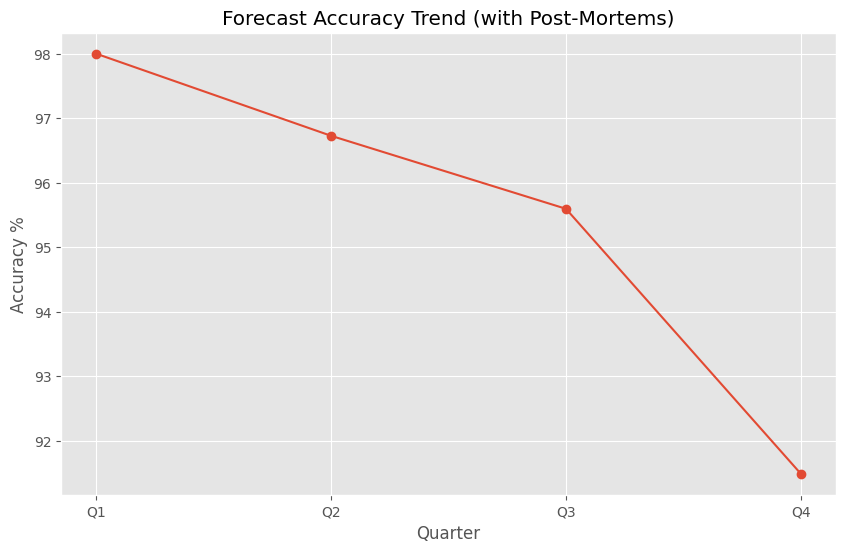

In [12]:
# Quarterly forecast vs actual data
forecast_data = pd.DataFrame({
  "quarter": ["Q1", "Q2", "Q3", "Q4"],
  "forecast": [1000, 1100, 1050, 1200],
  "actual": [980, 1150, 980, 1450],
  "external_factor": [0, 1, 0, 1],  # 1 = major event
  "planner_id": ["P1", "P2", "P1", "P2"]
})

# Calculate errors
forecast_data["error"] = forecast_data["actual"] - forecast_data["forecast"]
forecast_data["pct_error"] = forecast_data["error"] / forecast_data["forecast"] * 100
forecast_data["abs_error"] = abs(forecast_data["pct_error"])

# Systematic bias detection
planner_bias = forecast_data.groupby("planner_id")["pct_error"].mean()
print("Planner Bias Analysis:")
for planner, bias in planner_bias.items():
  if abs(bias) > 5:
    print(f"- {planner}: {'Over' if bias > 0 else 'Under'}-estimates by {bias:.1f}%")

# External factor impact
event_impact = forecast_data.groupby("external_factor")["abs_error"].mean()
print(f"\nError with external events: {event_impact[1]:.1f}%")
print(f"Error without events: {event_impact[0]:.1f}%")

# Statistical significance test
q1_q3_errors = forecast_data[forecast_data["quarter"].isin(["Q1", "Q3"])]["pct_error"]
q2_q4_errors = forecast_data[forecast_data["quarter"].isin(["Q2", "Q4"])]["pct_error"]

t_stat, p_value = stats.ttest_ind(q1_q3_errors, q2_q4_errors)
print(f"\nSeasonal bias significance: p={p_value:.3f}")

# Create autopsy report template
autopsy_template = pd.DataFrame({
  "question": [
    "What was the largest error source?",
    "Was bias systematic or random?",
    "What external factors were missed?",
    "What early warning signals existed?",
    "What process failed?"
  ],
  "answer": [
    "Holiday demand surge",
    "Systematic under-estimation in Q4",
    "None flagged",
    "Social media sentiment spike",
    "No pre-holiday demand sensing"
  ],
  "action_item": [
    "Implement ML promo model",
    "Add holiday multiplier",
    "Monitor social media",
    "Create alert threshold",
    "Add demand sensing layer"
  ]
})

print("\nAutopsy Report:")
display(autopsy_template)

# Track improvement over time
forecast_data["rolling_accuracy"] = 100 - forecast_data["abs_error"].expanding().mean()
plt.figure(figsize=(10, 6))
plt.plot(forecast_data["quarter"], forecast_data["rolling_accuracy"], marker="o")
plt.title("Forecast Accuracy Trend (with Post-Mortems)")
plt.ylabel("Accuracy %")
plt.xlabel("Quarter")
plt.show()